In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# ============================================================
# gpt-oss-120B assumptions from the supplied table
# ============================================================
dense_attention_layers = 18
sliding_window_layers = 18
sliding_window_tokens = 128
kv_heads = 8
head_dim = 64
kv_bytes_per_element = 2  # BF16

elements_per_token_per_layer = 2 * kv_heads * head_dim  # K + V = 1,024

prompt_tokens = 256_000
request_rate = 100
output_tokens = 1000

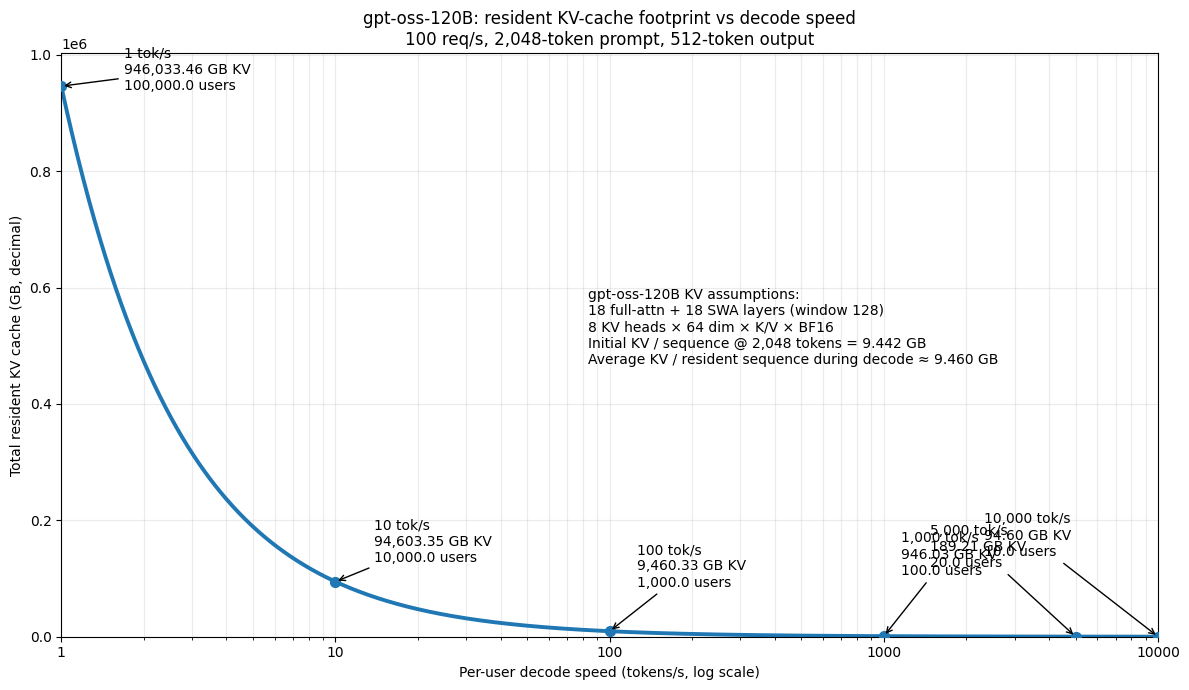

Elements / token / layer: 1,024
Initial KV / sequence at 2,048 tokens: 9.441903 GB
Supplied table value:                       0.080 GB
Average KV / sequence during 512-token decode: 9.460335 GB

     1 tok/s -> 100,000.00 resident users -> 946,033.459 GB total KV
    10 tok/s ->  10,000.00 resident users -> 94,603.346 GB total KV
   100 tok/s ->   1,000.00 resident users ->  9,460.335 GB total KV
 1,000 tok/s ->     100.00 resident users ->    946.033 GB total KV
 5,000 tok/s ->      20.00 resident users ->    189.207 GB total KV
10,000 tok/s ->      10.00 resident users ->     94.603 GB total KV


In [3]:
def kv_bytes_per_sequence(context_tokens):
    """
    KV bytes for one sequence at a given total context length.

    Full-attention layers retain the full context.
    Sliding-window layers retain at most 128 tokens.
    """
    dense_token_layers = dense_attention_layers * context_tokens
    swa_token_layers = sliding_window_layers * min(
        context_tokens, sliding_window_tokens
    )

    total_token_layers = dense_token_layers + swa_token_layers

    return (
        total_token_layers
        * elements_per_token_per_layer
        * kv_bytes_per_element
    )


# Check against the supplied table at the start of decode.
initial_kv_bytes = kv_bytes_per_sequence(prompt_tokens)
initial_kv_gb_decimal = initial_kv_bytes / 1e9

# During a 512-token decode, sequences are at different positions.
# Approximate the average resident sequence as halfway through decode.
avg_context_tokens = prompt_tokens + output_tokens / 2
avg_kv_bytes_per_sequence = kv_bytes_per_sequence(avg_context_tokens)
avg_kv_gb_decimal = avg_kv_bytes_per_sequence / 1e9


# ============================================================
# Little's Law:
#
# decode time/request = output_tokens / decode_speed
#
# resident sequences  = request_rate * decode time
#
# total resident KV   = resident sequences * avg KV / sequence
# ============================================================
def resident_sequences(decode_speed):
    return request_rate * output_tokens / decode_speed


def total_resident_kv_gb(decode_speed):
    return (
        resident_sequences(decode_speed)
        * avg_kv_bytes_per_sequence
        / 1e9
    )


# 1 -> 10,000 tokens/s
speeds = np.logspace(0, 4, 1200)
total_kv_gb = total_resident_kv_gb(speeds)

key_speeds = np.array([1, 10, 100, 1000, 5000, 10000], dtype=float)
key_kv_gb = total_resident_kv_gb(key_speeds)
key_users = resident_sequences(key_speeds)


# ============================================================
# Plot: log X, linear Y
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    speeds,
    total_kv_gb,
    linewidth=2.8,
    label="Resident KV cache"
)

ax.scatter(
    key_speeds,
    key_kv_gb,
    s=50,
    zorder=3
)

ax.set_xscale("log")
ax.set_xlim(1, 10000)
ax.set_ylim(0, key_kv_gb[0] * 1.06)

ax.set_xticks([1, 10, 100, 1000, 10000])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")

ax.set_xlabel("Per-user decode speed (tokens/s, log scale)")
ax.set_ylabel("Total resident KV cache (GB, decimal)")
ax.set_title(
    "gpt-oss-120B: resident KV-cache footprint vs decode speed\n"
    "100 req/s, 2,048-token prompt, 512-token output"
)

# Model / workload note
note = (
    f"gpt-oss-120B KV assumptions:\n"
    f"18 full-attn + 18 SWA layers (window 128)\n"
    f"8 KV heads × 64 dim × K/V × BF16\n"
    f"Initial KV / sequence @ 2,048 tokens = {initial_kv_gb_decimal:.3f} GB\n"
    f"Average KV / resident sequence during decode ≈ {avg_kv_gb_decimal:.3f} GB"
)
ax.text(
    0.48,
    0.53,
    note,
    transform=ax.transAxes,
    ha="left",
    va="center"
)

# Readable annotations
offsets = {
    1: (45, -5),
    10: (28, 12),
    100: (20, 30),
    1000: (12, 42),
    5000: (-105, 48),
    10000: (-125, 56),
}

for s, kv, users in zip(key_speeds, key_kv_gb, key_users):
    label = (
        f"{s:,.0f} tok/s\n"
        f"{kv:,.2f} GB KV\n"
        f"{users:,.1f} users"
    )

    ax.annotate(
        label,
        xy=(s, kv),
        xytext=offsets[int(s)],
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->"),
        ha="left",
        va="bottom"
    )

ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Elements / token / layer: {elements_per_token_per_layer:,}")
print(f"Initial KV / sequence at 2,048 tokens: {initial_kv_gb_decimal:.6f} GB")
print(f"Supplied table value:                       0.080 GB")
print(f"Average KV / sequence during 512-token decode: {avg_kv_gb_decimal:.6f} GB")
print()
for s, kv, users in zip(key_speeds, key_kv_gb, key_users):
    print(
        f"{s:>6,.0f} tok/s -> "
        f"{users:>10,.2f} resident users -> "
        f"{kv:>10,.3f} GB total KV"
    )


In [4]:
# ============================================================
# Serving assumptions
# ============================================================
request_rate = 100         # requests / second
output_tokens = 1024       # 1K output tokens

decode_speeds = [1, 10, 100, 1_000, 10_000]

# Interpret K as 1024 tokens
prompt_8k = 8 * 1024
prompt_256k = 256 * 1024

# ------------ FIX: Define sliding_window_size ---------------

# Add missing constant for sliding window retention
sliding_window_size = 128  # Sliding-window layers retain at most 128 tokens

def kv_bytes_per_sequence(context_tokens):
    """
    KV footprint for one resident sequence.

    Full-attention layers retain all context.
    Sliding-window layers retain at most 128 tokens.
    """
    full_attention_token_layers = (
        dense_attention_layers * context_tokens
    )

    sliding_window_token_layers = (
        sliding_window_layers
        * min(context_tokens, sliding_window_size)
    )

    total_token_layers = (
        full_attention_token_layers
        + sliding_window_token_layers
    )

    return (
        total_token_layers
        * elements_per_token_per_layer
        * kv_bytes_per_element
    )


def avg_kv_bytes_during_decode(prompt_tokens, output_tokens):
    """
    Approximate the average resident request as halfway through decode.
    """
    avg_context = prompt_tokens + output_tokens / 2
    return kv_bytes_per_sequence(avg_context)


def resident_users(decode_speed):
    """
    Little's Law for the decode phase.

    residence time = output_tokens / decode_speed
    resident users = request_rate * residence time
    """
    residence_time = output_tokens / decode_speed
    return request_rate * residence_time


# Average KV footprint per resident sequence
kv_per_user_8k = avg_kv_bytes_during_decode(
    prompt_8k, output_tokens
)

kv_per_user_256k = avg_kv_bytes_during_decode(
    prompt_256k, output_tokens
)

# ------------------------------------------------------------
# NEW: Display the KV cache for a single user (independent of time)
# ------------------------------------------------------------

def display_single_user_kv_cache():
    print("KV cache footprint for a single user request (resident for full duration):")
    kv_user_8k_bytes = kv_bytes_per_sequence(prompt_8k + output_tokens)
    kv_user_256k_bytes = kv_bytes_per_sequence(prompt_256k + output_tokens)
    print(f"  8K prompt + 1K decode:   {kv_user_8k_bytes/1e6:,.2f} MB  ({kv_user_8k_bytes/1e9:,.4f} GB)")
    print(f"256K prompt + 1K decode:   {kv_user_256k_bytes/1e6:,.2f} MB  ({kv_user_256k_bytes/1e9:,.4f} GB)")
    print()

display_single_user_kv_cache()

rows = []

for speed in decode_speeds:
    users = resident_users(speed)

    total_kv_8k_gb = users * kv_per_user_8k / 1e9
    total_kv_256k_gb = users * kv_per_user_256k / 1e9

    rows.append({
        "Decode speed": f"{speed:,} tok/s",
        "Resident users 8K:1K": users,
        "KV size 8K:1K (GB)": total_kv_8k_gb,
        "Resident users 256K:1K": users,
        "KV size 256K:1K (GB)": total_kv_256k_gb,
    })

df = pd.DataFrame(rows)

# Pretty formatting for better-looking table
from IPython.display import display, HTML

styled_df = (
    df.style
    .format({
        "Resident users 8K:1K": "{:,.2f}",
        "KV size 8K:1K (GB)": "{:,.2f}",
        "Resident users 256K:1K": "{:,.2f}",
        "KV size 256K:1K (GB)": "{:,.2f}",
    })
    .set_table_styles(
        [
            {"selector": "th", "props": [("font-size", "115%"), ("background-color", "#f2f2f2"), ("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "right"), ("padding", "5px 8px")]},
            {"selector": "tr:nth-child(even)", "props": [("background-color", "#fafbfc")]},
        ]
    )
    .set_properties(**{'border': '1px solid #d4d4d4'})
    .set_caption("Resident users and KV cache size at varying decode speeds")
    # .hide_index()  # Removed to fix AttributeError for older pandas versions
)

display(HTML("<style>caption { text-align: left; font-size: 120%; font-weight: bold; padding-bottom: 8px; }</style>"))
display(styled_df)

KV cache footprint for a single user request (resident for full duration):
  8K prompt + 1K decode:   344.46 MB  (0.3445 GB)
256K prompt + 1K decode:   9,706.14 MB  (9.7061 GB)



,Decode speed,Resident users 8K:1K,KV size 8K:1K (GB),Resident users 256K:1K,KV size 256K:1K (GB)
0,1 tok/s,"102,400.00","33,339.68","102,400.00","991,976.38"
1,10 tok/s,"10,240.00","3,333.97","10,240.00","99,197.64"
2,100 tok/s,"1,024.00",333.40,"1,024.00","9,919.76"
3,"1,000 tok/s",102.40,33.34,102.40,991.98
4,"10,000 tok/s",10.24,3.33,10.24,99.20


In [5]:
from IPython.display import display, HTML
import pandas as pd

# ============================================================
# gpt-oss-120B KV assumptions
# ============================================================
dense_attention_layers = 18
sliding_window_layers = 18
sliding_window_size = 128
kv_heads = 8
head_dim = 64

# NOTE:
# 1 byte/element = FP8 / INT8-like storage
# BF16 would be 2 bytes/element
kv_bytes_per_element = 1

# ============================================================
# Weights
# ============================================================
total_params_b = 116.8             # billions
weight_bytes_per_param = 0.5       # MXFP4

weights_gb = total_params_b * weight_bytes_per_param

elements_per_token_per_layer = 2 * kv_heads * head_dim  # K + V = 1,024

# ============================================================
# SRAM assumptions — TUNABLE
# ============================================================

clock_frequency_ghz = 2.0          # <-- CHANGE CLOCK HERE

sram_density_mb_per_mm2 = 1.0      # assumption: 1 MB SRAM = 1 mm²

# ============================================================
# Workloads
# ============================================================
output_tokens = 1024

prompt_8k = 8 * 1024
prompt_256k = 256 * 1024

decode_speeds = [1, 10, 100, 1_000, 10_000]

seconds_per_hour = 3600

# ============================================================
# KV calculations
# ============================================================

def kv_bytes_per_sequence(context_tokens):
    dense = dense_attention_layers * context_tokens
    swa = sliding_window_layers * min(
        context_tokens,
        sliding_window_size
    )
    return (
        (dense + swa)
        * elements_per_token_per_layer
        * kv_bytes_per_element
    )

def avg_kv_bytes_during_decode(prompt_tokens, output_tokens):
    avg_context = prompt_tokens + output_tokens / 2
    return kv_bytes_per_sequence(int(avg_context))

def users_served_per_hour(decode_speed, output_tokens):
    if decode_speed == 0:
        return 0

    return seconds_per_hour / (output_tokens / decode_speed)

# ============================================================
# Bandwidth calculations
# ============================================================

def required_bandwidth_gbs(
    decode_speed,
    kv_gb,
    batch_size=1
):
    """
    HBM / SRAM bandwidth needed to sustain decode_speed.

    For batch_size=1:

        BW = tok/s × (weights + KV)

    Returns GB/s.
    """
    return decode_speed * (
        weights_gb / batch_size
        + kv_gb
    )

# ============================================================
# SRAM calculations
# ============================================================

def sram_area_kv_only_mm2(kv_gb):
    """
    Silicon area if ONLY the KV cache is stored in SRAM.

    Using decimal units:
        1 GB = 1000 MB
        1 MB SRAM = 1 mm²
    """
    kv_mb = kv_gb * 1000
    return kv_mb / sram_density_mb_per_mm2

def sram_area_weights_plus_kv_mm2(kv_gb):
    """
    Silicon area if BOTH model weights and KV cache
    are stored in SRAM.
    """
    total_sram_gb = weights_gb + kv_gb
    total_sram_mb = total_sram_gb * 1000
    return total_sram_mb / sram_density_mb_per_mm2

def required_sram_width_bits_per_cycle(bandwidth_gbs):
    """
    Aggregate SRAM read width required to deliver a given
    bandwidth at the selected clock frequency.

    Since:

        GB/s / GHz = bytes/cycle

    therefore:

        bits/cycle = (GB/s / GHz) × 8
    """
    bytes_per_cycle = bandwidth_gbs / clock_frequency_ghz
    return bytes_per_cycle * 8

def required_sram_width_bytes_per_cycle(bandwidth_gbs):
    """
    Same calculation, expressed as bytes transferred per clock.
    """
    return bandwidth_gbs / clock_frequency_ghz

# ============================================================
# Compute KV sizes
# ============================================================

kv_8k_gb = (
    avg_kv_bytes_during_decode(
        prompt_8k,
        output_tokens
    )
    / 1e9
)

kv_256k_gb = (
    avg_kv_bytes_during_decode(
        prompt_256k,
        output_tokens
    )
    / 1e9
)

# ============================================================
# Build tables (separately for 8K/1K and 256K/1K)
# ============================================================

# --- 8K/1K Table ---
rows_8k = []
for speed in decode_speeds:
    users_hour = users_served_per_hour(speed, output_tokens)
    bw_8k = required_bandwidth_gbs(speed, kv_8k_gb)
    rows_8k.append({
        # General
        "Decode speed": f"{speed:,} tok/s",
        "Nb users served/hour": users_hour,
        "KV 8K (GB)": kv_8k_gb,
        "BW 8K (GB/s)": bw_8k,
        "SRAM KV-only 8K (mm²)": sram_area_kv_only_mm2(kv_8k_gb),
        "SRAM W+KV 8K (mm²)": sram_area_weights_plus_kv_mm2(kv_8k_gb),
        f"SRAM width 8K @ {clock_frequency_ghz:g}GHz (bits/cycle)": required_sram_width_bits_per_cycle(bw_8k),
    })
df_8k = pd.DataFrame(rows_8k)

fmt_8k = df_8k.copy()
for c in fmt_8k.columns[1:]:
    fmt_8k[c] = fmt_8k[c].map(
        lambda x: f"{x:,.1f}" if x >= 1 else f"{x:,.3f}"
    )

styled_fmt_8k = (
    fmt_8k.style
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("font-size", "110%"),
                    ("background-color", "#f2f2f2"),
                    ("text-align", "center"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "right"),
                    ("padding", "5px 8px"),
                ],
            },
            {
                "selector": "tr:nth-child(even)",
                "props": [
                    ("background-color", "#fafbfc")
                ],
            },
        ]
    )
    .set_properties(
        **{"border": "1px solid #d4d4d4"}
    )
    .set_caption(
        f"8K/1K: Memory, bandwidth and SRAM silicon requirements "
        f"— SRAM clock = {clock_frequency_ghz:g} GHz, "
        f"density = {sram_density_mb_per_mm2:g} MB/mm²"
    )
)

# --- 256K/1K Table ---
rows_256k = []
for speed in decode_speeds:
    users_hour = users_served_per_hour(speed, output_tokens)
    bw_256k = required_bandwidth_gbs(speed, kv_256k_gb)
    rows_256k.append({
        # General
        "Decode speed": f"{speed:,} tok/s",
        "Nb users served/hour": users_hour,
        "KV 256K (GB)": kv_256k_gb,
        "BW 256K (GB/s)": bw_256k,
        "SRAM KV-only 256K (mm²)": sram_area_kv_only_mm2(kv_256k_gb),
        "SRAM W+KV 256K (mm²)": sram_area_weights_plus_kv_mm2(kv_256k_gb),
        f"SRAM width 256K @ {clock_frequency_ghz:g}GHz (bits/cycle)": required_sram_width_bits_per_cycle(bw_256k),
    })
df_256k = pd.DataFrame(rows_256k)

fmt_256k = df_256k.copy()
for c in fmt_256k.columns[1:]:
    fmt_256k[c] = fmt_256k[c].map(
        lambda x: f"{x:,.1f}" if x >= 1 else f"{x:,.3f}"
    )

styled_fmt_256k = (
    fmt_256k.style
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("font-size", "110%"),
                    ("background-color", "#f2f2f2"),
                    ("text-align", "center"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "right"),
                    ("padding", "5px 8px"),
                ],
            },
            {
                "selector": "tr:nth-child(even)",
                "props": [
                    ("background-color", "#fafbfc")
                ],
            },
        ]
    )
    .set_properties(
        **{"border": "1px solid #d4d4d4"}
    )
    .set_caption(
        f"256K/1K: Memory, bandwidth and SRAM silicon requirements "
        f"— SRAM clock = {clock_frequency_ghz:g} GHz, "
        f"density = {sram_density_mb_per_mm2:g} MB/mm²"
    )
)

# Shared table style for both
display(
    HTML(
        """
        <style>
        caption {
            text-align: left;
            font-size: 120%;
            font-weight: bold;
            padding-bottom: 8px;
        }
        </style>
        """
    )
)

display(styled_fmt_8k)
display(styled_fmt_256k)

# ============================================================
# Print all main input values for traceability
# ============================================================
print("\n--- Inputs ---")
print(f"KV precision = {kv_bytes_per_element}")
print(f"Weight precision = {weight_bytes_per_param}")
print(f"Clock = {clock_frequency_ghz}")
print(f"Assumed SRAM density = {sram_density_mb_per_mm2}")

,Decode speed,Nb users served/hour,KV 8K (GB),BW 8K (GB/s),SRAM KV-only 8K (mm²),SRAM W+KV 8K (mm²),SRAM width 8K @ 2GHz (bits/cycle)
0,1 tok/s,3.5,0.163,58.6,162.8,"58,562.8",234.3
1,10 tok/s,35.2,0.163,585.6,162.8,"58,562.8","2,342.5"
2,100 tok/s,351.6,0.163,"5,856.3",162.8,"58,562.8","23,425.1"
3,"1,000 tok/s","3,515.6",0.163,"58,562.8",162.8,"58,562.8","234,251.2"
4,"10,000 tok/s","35,156.2",0.163,"585,627.9",162.8,"58,562.8","2,342,511.7"


,Decode speed,Nb users served/hour,KV 256K (GB),BW 256K (GB/s),SRAM KV-only 256K (mm²),SRAM W+KV 256K (mm²),SRAM width 256K @ 2GHz (bits/cycle)
0,1 tok/s,3.5,4.8,63.2,"4,843.6","63,243.6",253.0
1,10 tok/s,35.2,4.8,632.4,"4,843.6","63,243.6","2,529.7"
2,100 tok/s,351.6,4.8,"6,324.4","4,843.6","63,243.6","25,297.5"
3,"1,000 tok/s","3,515.6",4.8,"63,243.6","4,843.6","63,243.6","252,974.5"
4,"10,000 tok/s","35,156.2",4.8,"632,436.3","4,843.6","63,243.6","2,529,745.4"



--- Inputs ---
KV precision = 1
Weight precision = 0.5
Clock = 2.0
Assumed SRAM density = 1.0


Precision               Weights (GB)  Wall (tok/s)  Plateau (users)
FP4  (0.5 B/param)              58.4         102.7              584
FP8  (1 B/param)               116.8          51.4              414
BF16 (2 B/param)               233.6          25.7               74


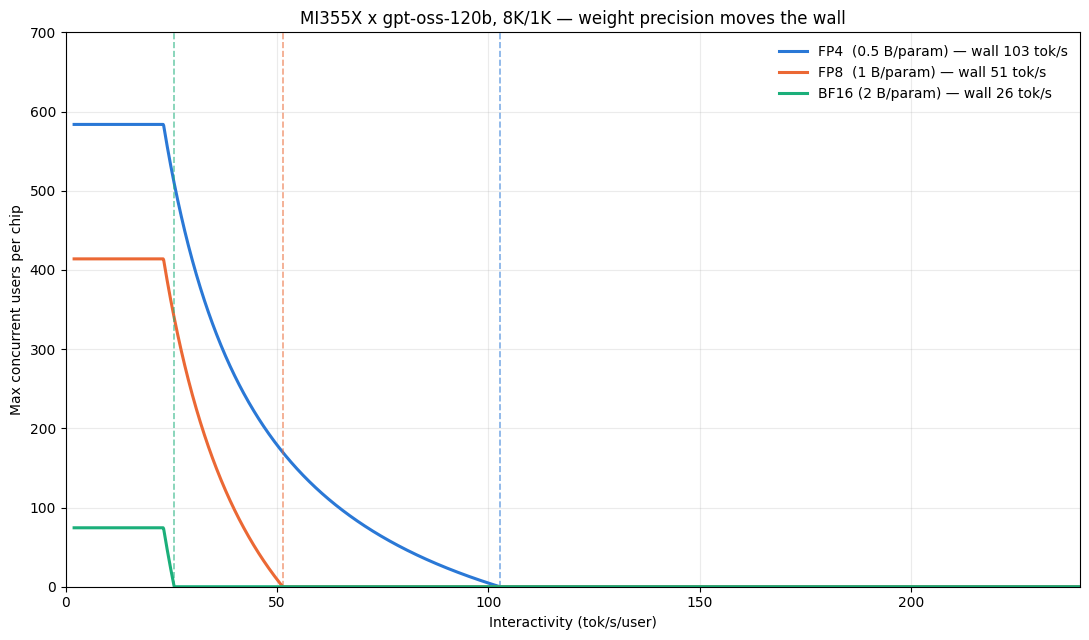

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUTS — tune these
# ============================================================
WEIGHT_PRECISIONS = {          # bytes/param -> label
    0.5:  "FP4  (0.5 B/param)",
    1.0:  "FP8  (1 B/param)",
    2.0:  "BF16 (2 B/param)",
}
TOTAL_PARAMS_B = 116.8         # gpt-oss-120b total params (billions)
BW_RAW   = 8000.0              # MI355X HBM bandwidth (GB/s)
MBU      = 0.75                # achievable bandwidth utilization
HBM      = 288 * 0.9           # usable HBM (GB)
KV_GB    = 0.344               # KV per user (GB), 8K/1K peak context, BF16 KV

BW_EFF = BW_RAW * MBU
COLORS = {0.5: "#2a78d6", 1.0: "#eb6834", 2.0: "#1baf7a"}

def max_users(I, W):
    n_mem = (HBM - W) / KV_GB               # HBM plateau (weights also shrink!)
    n_bw  = (BW_EFF / I - W) / KV_GB
    return np.clip(np.minimum(n_mem, n_bw), 0, None)

I = np.linspace(2, 240, 2000)
fig, ax = plt.subplots(figsize=(11, 6.5))

print(f"{'Precision':<22}{'Weights (GB)':>14}{'Wall (tok/s)':>14}{'Plateau (users)':>17}")
for bpp, label in WEIGHT_PRECISIONS.items():
    W = TOTAL_PARAMS_B * bpp               # weight bytes read per step (GB)
    wall = BW_EFF / W
    plateau = (HBM - W) / KV_GB
    ax.plot(I, max_users(I, W), lw=2.2, color=COLORS[bpp], label=f"{label} — wall {wall:.0f} tok/s")
    ax.axvline(wall, ls="--", lw=1.2, color=COLORS[bpp], alpha=0.6)
    print(f"{label:<22}{W:>14.1f}{wall:>14.1f}{plateau:>17.0f}")

ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Max concurrent users per chip")
ax.set_title("MI355X x gpt-oss-120b, 8K/1K — weight precision moves the wall")
ax.set_xlim(0, 240); ax.set_ylim(0, 700)
ax.legend(frameon=False); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig("mi355x_wall_precision.png", dpi=150)


Added 19 additional models. Total models = 35


,Release date,Model,Architecture,Native context,256K:1K native,Peak KV / state (GB)
0,2023-02-27,LLaMA-7B,MHA,"2,048",No — extrapolated,137.98
1,2023-07-18,Llama 2 70B,GQA,"4,096",No — extrapolated,86.23
2,2023-09-27,Mistral 7B,GQA + SWA,"32,768",No — extrapolated,0.54
3,2023-12-11,Mixtral 8x7B,GQA + SWA + MoE,"32,768",No — extrapolated,0.54
4,2024-02-01,OLMo 1 7B,MHA,"2,048",No — extrapolated,137.98
5,2024-02-21,Gemma 1 7B,MHA,"8,192",No — extrapolated,120.73
6,2024-04-17,Mixtral 8x22B,GQA + MoE,"65,536",No — extrapolated,60.36
7,2024-04-18,Llama 3 70B,GQA,"8,192",No — extrapolated,86.23
8,2024-04-18,Llama 3 8B,GQA,"8,192",No — extrapolated,34.49
9,2024-05-06,DeepSeek-V2,MLA,"163,840",No — extrapolated,18.19


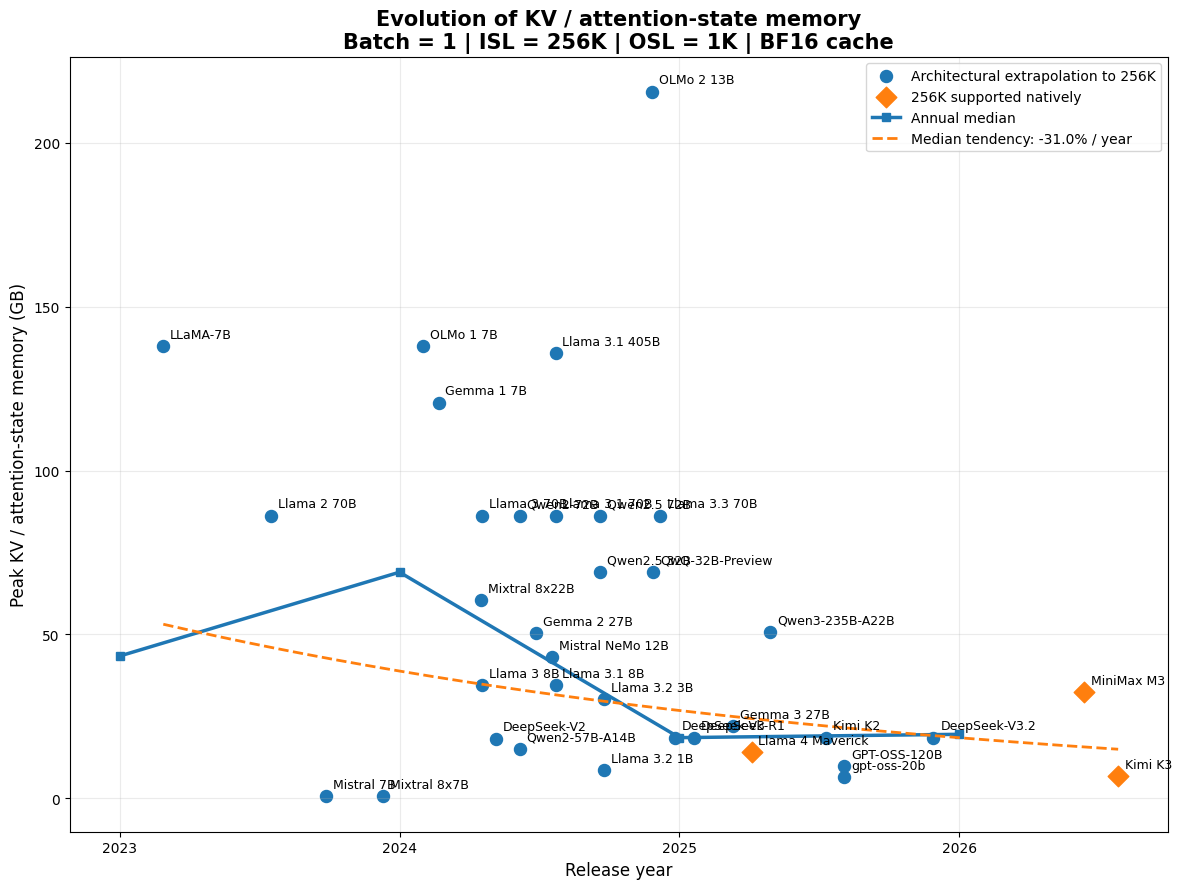


--- WORKLOAD ---
ISL               = 262,144 tokens
OSL               = 1,024 tokens
Peak sequence     = 263,168 tokens
Batch size        = 1
KV precision      = 2 bytes/element

--- ALL-MODEL LOG-LINEAR FIT ---
Annual change     = -25.8% / year
Annual factor     = 0.742x
R²                = 0.025

--- ANNUAL-MEDIAN LOG-LINEAR FIT ---
Annual change     = -31.0% / year
Annual factor     = 0.690x
R²                = 0.562

--- ANNUAL MEDIAN KV / STATE ---
2023: 43.39 GB
2024: 68.99 GB
2025: 18.49 GB
2026: 19.51 GB

--- ENDPOINT COMPARISON ---
LLaMA-7B: 137.98 GB
Kimi K3: 6.68 GB
Reduction = 20.6x


In [7]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# GLOBAL ASSUMPTIONS
# ============================================================

batch_size = 1

input_tokens = 256 * 1024
output_tokens = 1 * 1024

# Peak cache = cache at END of decode
total_tokens = input_tokens + output_tokens

# BF16 KV / attention state
kv_bytes_per_element = 2

# For Kimi K3 recurrent KDA state.
# Set to 4 if you want to model FP32 recurrent state instead.
kda_state_bytes_per_element = 2


# ============================================================
# MODEL DATABASE
#
# "standard":
#     normal MHA / GQA KV cache
#
# "mla":
#     compressed Multi-head Latent Attention cache
#
# "kda_mla":
#     Kimi K3 hybrid:
#     token-growing MLA state + fixed recurrent KDA state
# ============================================================

models = [

    # --------------------------------------------------------
    # 2023
    # --------------------------------------------------------

    {
        "model": "LLaMA-7B",
        "release_date": "2023-02-27",
        "architecture": "MHA",
        "native_context": 2_048,

        "kind": "standard",

        "layers": 32,
        "kv_heads": 32,
        "head_dim": 128,

        "full_layers": 32,
        "local_layers": 0,
        "window": None,
    },

    {
        "model": "Llama 2 70B",
        "release_date": "2023-07-18",
        "architecture": "GQA",
        "native_context": 4_096,

        "kind": "standard",

        "layers": 80,
        "kv_heads": 8,
        "head_dim": 128,

        "full_layers": 80,
        "local_layers": 0,
        "window": None,
    },

    {
        "model": "Mistral 7B",
        "release_date": "2023-09-27",
        "architecture": "GQA + SWA",
        "native_context": 32_768,

        "kind": "standard",

        "layers": 32,
        "kv_heads": 8,
        "head_dim": 128,

        # All layers use the 4K sliding window
        "full_layers": 0,
        "local_layers": 32,
        "window": 4_096,
    },

    {
        "model": "Mixtral 8x7B",
        "release_date": "2023-12-11",
        "architecture": "GQA + SWA + MoE",
        "native_context": 32_768,

        "kind": "standard",

        # MoE changes FFN, not attention-side KV dimensions
        "layers": 32,
        "kv_heads": 8,
        "head_dim": 128,

        "full_layers": 0,
        "local_layers": 32,
        "window": 4_096,
    },


    # --------------------------------------------------------
    # 2024
    # --------------------------------------------------------

    {
        "model": "DeepSeek-V2",
        "release_date": "2024-05-06",
        "architecture": "MLA",
        "native_context": 163_840,

        "kind": "mla",

        "layers": 60,

        # Compressed KV latent
        "kv_lora_rank": 512,

        # RoPE component cached separately
        "rope_cache_dim": 64,
    },

    {
        "model": "Llama 3.1 405B",
        "release_date": "2024-07-23",
        "architecture": "GQA",
        "native_context": 131_072,

        "kind": "standard",

        "layers": 126,
        "kv_heads": 8,
        "head_dim": 128,

        "full_layers": 126,
        "local_layers": 0,
        "window": None,
    },

    {
        "model": "Qwen2.5 72B",
        "release_date": "2024-09-19",
        "architecture": "GQA",
        "native_context": 131_072,

        "kind": "standard",

        "layers": 80,
        "kv_heads": 8,
        "head_dim": 128,

        "full_layers": 80,
        "local_layers": 0,
        "window": None,
    },

    {
        "model": "DeepSeek-V3",
        "release_date": "2024-12-26",
        "architecture": "MLA + MoE",
        "native_context": 163_840,

        "kind": "mla",

        "layers": 61,
        "kv_lora_rank": 512,
        "rope_cache_dim": 64,
    },


    # --------------------------------------------------------
    # 2025
    # --------------------------------------------------------

    {
        "model": "Gemma 3 27B",
        "release_date": "2025-03-12",
        "architecture": "GQA + 5:1 local/global",
        "native_context": 131_072,

        "kind": "standard",

        "layers": 62,
        "kv_heads": 16,
        "head_dim": 128,

        # 62 layers:
        # approximately 52 local + 10 global
        "full_layers": 10,
        "local_layers": 52,
        "window": 1_024,
    },

    {
        "model": "Llama 4 Maverick",
        "release_date": "2025-04-05",
        "architecture": "GQA + chunked/full attention",
        "native_context": 1_048_576,

        "kind": "standard",

        "layers": 48,
        "kv_heads": 8,
        "head_dim": 128,

        # 1 full layer every 4 layers
        "full_layers": 12,
        "local_layers": 36,
        "window": 8_192,
    },

    {
        "model": "Qwen3-235B-A22B",
        "release_date": "2025-04-29",
        "architecture": "GQA + MoE",
        "native_context": 40_960,

        "kind": "standard",

        "layers": 94,
        "kv_heads": 4,
        "head_dim": 128,

        "full_layers": 94,
        "local_layers": 0,
        "window": None,
    },

    {
        "model": "Kimi K2",
        "release_date": "2025-07-11",
        "architecture": "MLA + MoE",
        "native_context": 131_072,

        "kind": "mla",

        "layers": 61,
        "kv_lora_rank": 512,
        "rope_cache_dim": 64,
    },

    {
        "model": "GPT-OSS-120B",
        "release_date": "2025-08-04",
        "architecture": "GQA + alternating SWA/full",
        "native_context": 131_072,

        "kind": "standard",

        "layers": 36,
        "kv_heads": 8,
        "head_dim": 64,

        # 18 full attention
        # 18 sliding-window attention
        "full_layers": 18,
        "local_layers": 18,
        "window": 128,
    },

    {
        "model": "DeepSeek-V3.2",
        "release_date": "2025-11-28",
        "architecture": "MLA + sparse attention",
        "native_context": 163_840,

        "kind": "mla",

        "layers": 61,
        "kv_lora_rank": 512,
        "rope_cache_dim": 64,

        # Sparse-index metadata is NOT included in KV size.
    },


    # --------------------------------------------------------
    # 2026
    # --------------------------------------------------------

    {
        "model": "MiniMax M3",
        "release_date": "2026-06-12",
        "architecture": "GQA + sparse block attention",
        "native_context": 1_048_576,

        "kind": "standard",

        "layers": 60,
        "kv_heads": 4,
        "head_dim": 128,

        # Sparse attention reduces which KV blocks are READ,
        # but the raw historical KV is still retained here.
        "full_layers": 60,
        "local_layers": 0,
        "window": None,
    },

    {
        "model": "Kimi K3",
        "release_date": "2026-07-27",
        "architecture": "24 Gated-MLA + 69 KDA",
        "native_context": 1_048_576,

        "kind": "kda_mla",

        # Token-growing MLA layers
        "mla_layers": 24,
        "kv_lora_rank": 512,

        # Released config has mla_use_nope=True.
        # Therefore use only the 512-d latent cache here.
        "rope_cache_dim": 0,

        # Fixed recurrent KDA state
        "kda_layers": 69,
        "kda_heads": 96,
        "kda_head_dim": 128,
    },
]


# ============================================================
# ADD 20 MORE REPRESENTATIVE MODELS
#
# These are appended to the original model database.
#
# IMPORTANT:
# release_date is mainly used to position models within a year.
# The trend should primarily be interpreted at yearly scale.
# ============================================================

additional_models = [

    # ========================================================
    # 2024
    # ========================================================


    # --------------------------------------------------------
    # Gemma 1 7B
    #
    # 28 layers
    # 16 Q heads
    # 16 KV heads -> MHA
    # head size = 256
    # --------------------------------------------------------
    {
        "model": "Gemma 1 7B",
        "release_date": "2024-02-21",
        "architecture": "MHA",
        "native_context": 8_192,
        "kind": "standard",
        "layers": 28,
        "kv_heads": 16,
        "head_dim": 256,
        "full_layers": 28,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # OLMo 1 7B
    #
    # 32 layers
    # 32 Q heads
    # 32 KV heads -> MHA
    # hidden_size = 4096 -> head_dim = 128
    # --------------------------------------------------------
    {
        "model": "OLMo 1 7B",
        "release_date": "2024-02-01",
        "architecture": "MHA",
        "native_context": 2_048,
        "kind": "standard",
        "layers": 32,
        "kv_heads": 32,
        "head_dim": 128,
        "full_layers": 32,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Llama 3 8B
    #
    # 32 layers
    # 8 KV heads
    # head_dim = 128
    # --------------------------------------------------------
    {
        "model": "Llama 3 8B",
        "release_date": "2024-04-18",
        "architecture": "GQA",
        "native_context": 8_192,
        "kind": "standard",
        "layers": 32,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 32,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Llama 3 70B
    # --------------------------------------------------------
    {
        "model": "Llama 3 70B",
        "release_date": "2024-04-18",
        "architecture": "GQA",
        "native_context": 8_192,
        "kind": "standard",
        "layers": 80,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 80,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Mixtral 8x22B
    #
    # MoE affects FFN parameters, not KV cache dimensions.
    # --------------------------------------------------------
    {
        "model": "Mixtral 8x22B",
        "release_date": "2024-04-17",
        "architecture": "GQA + MoE",
        "native_context": 65_536,
        "kind": "standard",
        "layers": 56,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 56,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Qwen2-72B
    #
    # 80 layers
    # 64 Q heads
    # 8 KV heads
    # --------------------------------------------------------
    {
        "model": "Qwen2-72B",
        "release_date": "2024-06-06",
        "architecture": "GQA",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 80,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 80,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Qwen2-57B-A14B
    #
    # 28 layers
    # 4 KV heads
    # MoE does not multiply KV cache.
    # --------------------------------------------------------
    {
        "model": "Qwen2-57B-A14B",
        "release_date": "2024-06-06",
        "architecture": "GQA + MoE",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 28,
        "kv_heads": 4,
        "head_dim": 128,
        "full_layers": 28,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Gemma 2 27B
    #
    # 46 layers
    # alternating global / local attention
    #
    # Approximation:
    # 23 global layers
    # 23 local layers
    # local window = 4096
    # --------------------------------------------------------
    {
        "model": "Gemma 2 27B",
        "release_date": "2024-06-27",
        "architecture": "GQA + local/global",
        "native_context": 8_192,
        "kind": "standard",
        "layers": 46,
        "kv_heads": 16,
        "head_dim": 128,
        "full_layers": 23,
        "local_layers": 23,
        "window": 4_096,
    },

    # --------------------------------------------------------
    # Mistral NeMo 12B
    #
    # 40 layers
    # 8 KV heads
    # 128-d heads
    # --------------------------------------------------------
    {
        "model": "Mistral NeMo 12B",
        "release_date": "2024-07-18",
        "architecture": "GQA",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 40,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 40,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Llama 3.1 8B
    # --------------------------------------------------------
    {
        "model": "Llama 3.1 8B",
        "release_date": "2024-07-23",
        "architecture": "GQA",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 32,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 32,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Llama 3.1 70B
    # --------------------------------------------------------
    {
        "model": "Llama 3.1 70B",
        "release_date": "2024-07-23",
        "architecture": "GQA",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 80,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 80,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Llama 3.2 1B
    #
    # hidden_size = 2048
    # 32 attention heads
    # -> head_dim = 64
    # --------------------------------------------------------
    {
        "model": "Llama 3.2 1B",
        "release_date": "2024-09-25",
        "architecture": "GQA",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 16,
        "kv_heads": 8,
        "head_dim": 64,
        "full_layers": 16,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Llama 3.2 3B
    # --------------------------------------------------------
    {
        "model": "Llama 3.2 3B",
        "release_date": "2024-09-25",
        "architecture": "GQA",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 28,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 28,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Qwen2.5 32B
    #
    # 64 layers
    # 40 Q heads
    # 8 KV heads
    # SWA disabled in released config
    # --------------------------------------------------------
    {
        "model": "Qwen2.5 32B",
        "release_date": "2024-09-19",
        "architecture": "GQA",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 64,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 64,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # OLMo 2 13B
    #
    # 40 layers
    # 40 attention heads
    # 40 KV heads -> full MHA
    # --------------------------------------------------------
    {
        "model": "OLMo 2 13B",
        "release_date": "2024-11-26",
        "architecture": "MHA",
        "native_context": 4_096,
        "kind": "standard",
        "layers": 40,
        "kv_heads": 40,
        "head_dim": 128,
        "full_layers": 40,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # QwQ-32B-Preview
    #
    # Qwen2 architecture
    # 64 layers
    # 8 KV heads
    # --------------------------------------------------------
    {
        "model": "QwQ-32B-Preview",
        "release_date": "2024-11-28",
        "architecture": "GQA",
        "native_context": 32_768,
        "kind": "standard",
        "layers": 64,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 64,
        "local_layers": 0,
        "window": None,
    },

    # --------------------------------------------------------
    # Llama 3.3 70B
    # --------------------------------------------------------
    {
        "model": "Llama 3.3 70B",
        "release_date": "2024-12-06",
        "architecture": "GQA",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 80,
        "kv_heads": 8,
        "head_dim": 128,
        "full_layers": 80,
        "local_layers": 0,
        "window": None,
    },

    # ========================================================
    # 2025
    # ========================================================

    # --------------------------------------------------------
    # DeepSeek-R1
    #
    # Same MLA family as DeepSeek-V3:
    #
    # 61 layers
    # compressed KV latent = 512
    # cached RoPE component = 64
    #
    # NOTE:
    # MLA does NOT cache conventional full K + V tensors.
    # --------------------------------------------------------
    {
        "model": "DeepSeek-R1",
        "release_date": "2025-01-20",
        "architecture": "MLA + MoE",
        "native_context": 163_840,
        "kind": "mla",
        "layers": 61,
        "kv_lora_rank": 512,
        "rope_cache_dim": 64,
    },

    # --------------------------------------------------------
    # gpt-oss-20b
    #
    # 24 layers total:
    # 12 full attention
    # 12 sliding attention
    #
    # 8 KV heads
    # head_dim = 64
    # window = 128
    # --------------------------------------------------------
    {
        "model": "gpt-oss-20b",
        "release_date": "2025-08-04",
        "architecture": "GQA + alternating SWA/full",
        "native_context": 131_072,
        "kind": "standard",
        "layers": 24,
        "kv_heads": 8,
        "head_dim": 64,
        "full_layers": 12,
        "local_layers": 12,
        "window": 128,
    },

]

# ============================================================
# APPEND WITHOUT DUPLICATING MODELS IF CELL IS RE-RUN
# ============================================================

existing_model_names = {
    m["model"]
    for m in models
}

models_to_add = [
    m
    for m in additional_models
    if m["model"] not in existing_model_names
]

models.extend(models_to_add)

print(
    f"Added {len(models_to_add)} additional models. "
    f"Total models = {len(models)}"
)


# ============================================================
# CACHE CALCULATION
# ============================================================

def calculate_cache_bytes(m):

    # --------------------------------------------------------
    # Standard MHA / GQA / local attention
    # --------------------------------------------------------

    if m["kind"] == "standard":

        # K + V
        bytes_per_token_per_layer = (
            m["kv_heads"]
            * m["head_dim"]
            * 2
            * kv_bytes_per_element
        )

        # Full-attention layers retain entire sequence.
        full_positions = (
            m["full_layers"]
            * total_tokens
        )

        # Local/sliding layers retain only their window.
        if m["local_layers"] > 0:

            local_tokens = min(
                total_tokens,
                m["window"]
            )

            local_positions = (
                m["local_layers"]
                * local_tokens
            )

        else:
            local_positions = 0

        return (
            bytes_per_token_per_layer
            * (full_positions + local_positions)
            * batch_size
        )


    # --------------------------------------------------------
    # MLA
    #
    # KV is compressed into ONE latent representation,
    # therefore there is no normal "* 2 for K + V".
    # --------------------------------------------------------

    elif m["kind"] == "mla":

        cached_elements_per_token_per_layer = (
            m["kv_lora_rank"]
            + m["rope_cache_dim"]
        )

        return (
            m["layers"]
            * cached_elements_per_token_per_layer
            * kv_bytes_per_element
            * total_tokens
            * batch_size
        )


    # --------------------------------------------------------
    # Kimi K3:
    # token-growing MLA + fixed recurrent KDA state
    # --------------------------------------------------------

    elif m["kind"] == "kda_mla":

        # MLA token-dependent state
        mla_elements = (
            m["kv_lora_rank"]
            + m["rope_cache_dim"]
        )

        mla_bytes = (
            m["mla_layers"]
            * mla_elements
            * kv_bytes_per_element
            * total_tokens
            * batch_size
        )

        # Approximate KDA recurrent matrix state:
        #
        #     [heads, head_dim, head_dim]
        #
        # per KDA layer.
        #
        # This state does NOT grow with context length.
        kda_bytes = (
            m["kda_layers"]
            * m["kda_heads"]
            * m["kda_head_dim"]
            * m["kda_head_dim"]
            * kda_state_bytes_per_element
            * batch_size
        )

        return mla_bytes + kda_bytes


    else:
        raise ValueError(
            f"Unknown cache type: {m['kind']}"
        )


# ============================================================
# BUILD DATAFRAME
# ============================================================

rows = []

for m in models:

    cache_bytes = calculate_cache_bytes(m)

    native_256k = (
        m["native_context"]
        >= total_tokens
    )

    rows.append(
        {
            "Model": m["model"],
            "Release date": pd.to_datetime(
                m["release_date"]
            ),
            "Architecture": m["architecture"],
            "Native context": m["native_context"],
            "256K:1K native": native_256k,
            "Peak KV / state (GB)": cache_bytes / 1e9,
            "Peak KV / state (GiB)": cache_bytes / (1024**3),
        }
    )


df = pd.DataFrame(rows)

df = df.sort_values(
    "Release date"
).reset_index(drop=True)

df["Year"] = df["Release date"].dt.year


# ============================================================
# DECIMAL YEAR
#
# Gives us 2024.5 etc. so models released in the same
# year do not overlap on the plot.
# ============================================================

def decimal_year(ts):

    start = pd.Timestamp(
        year=ts.year,
        month=1,
        day=1
    )

    end = pd.Timestamp(
        year=ts.year + 1,
        month=1,
        day=1
    )

    fraction = (
        (ts - start)
        / (end - start)
    )

    return ts.year + fraction


df["Year decimal"] = (
    df["Release date"]
    .map(decimal_year)
    .astype(float)
)


# ============================================================
# DISPLAY TABLE
# ============================================================

display_df = df[
    [
        "Release date",
        "Model",
        "Architecture",
        "Native context",
        "256K:1K native",
        "Peak KV / state (GB)",
    ]
].copy()

display_df["Release date"] = (
    display_df["Release date"]
    .dt.strftime("%Y-%m-%d")
)

display_df["Native context"] = (
    display_df["Native context"]
    .map(lambda x: f"{x:,}")
)

display_df["256K:1K native"] = (
    display_df["256K:1K native"]
    .map({
        True: "Yes",
        False: "No — extrapolated"
    })
)


styled = (
    display_df.style

    .format(
        {
            "Peak KV / state (GB)":
                "{:,.2f}"
        }
    )

    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("font-size", "110%"),
                    ("background-color", "#f2f2f2"),
                    ("text-align", "center"),
                ],
            },

            {
                "selector": "td",
                "props": [
                    ("padding", "5px 8px"),
                ],
            },
        ]
    )

    .set_caption(
        "Peak BF16 KV / attention-state memory "
        "— batch 1, ISL 256K, OSL 1K"
    )
)


display(
    HTML(
        """
        <style>
        caption {
            text-align: left;
            font-size: 120%;
            font-weight: bold;
            padding-bottom: 8px;
        }
        </style>
        """
    )
)

display(styled)


# ============================================================
# TREND FUNCTIONS
#
# We fit:
#
#     ln(KV) = a + b * year
#
# Therefore:
#
#     KV = exp(a) * exp(b * year)
#
# Annual multiplicative factor = exp(b)
#
# Example:
# exp(b) = 0.80  ->  -20% / year
# ============================================================

def log_linear_trend(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    log_y = np.log(y)

    slope, intercept = np.polyfit(
        x,
        log_y,
        1
    )

    predicted_log_y = (
        intercept
        + slope * x
    )

    ss_res = np.sum(
        (log_y - predicted_log_y) ** 2
    )

    ss_tot = np.sum(
        (log_y - np.mean(log_y)) ** 2
    )

    r_squared = (
        1 - ss_res / ss_tot
        if ss_tot != 0
        else np.nan
    )

    annual_factor = np.exp(slope)

    annual_change_pct = (
        annual_factor - 1
    ) * 100

    return {
        "slope": slope,
        "intercept": intercept,
        "annual_factor": annual_factor,
        "annual_change_pct": annual_change_pct,
        "r_squared": r_squared,
    }


# ============================================================
# TREND 1:
# ALL INDIVIDUAL MODELS
# ============================================================

all_model_trend = log_linear_trend(
    df["Year decimal"],
    df["Peak KV / state (GB)"]
)


# ============================================================
# TREND 2:
# ANNUAL MEDIAN
#
# This is less sensitive to one unusual architecture/model.
# ============================================================

annual_median = (
    df.groupby("Year")[
        "Peak KV / state (GB)"
    ]
    .median()
)

median_trend = log_linear_trend(
    annual_median.index,
    annual_median.values
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 9)
)


# ------------------------------------------------------------
# Individual models
# ------------------------------------------------------------

native = df[
    df["256K:1K native"]
]

extrapolated = df[
    ~df["256K:1K native"]
]


ax.scatter(
    extrapolated["Year decimal"],
    extrapolated["Peak KV / state (GB)"],
    s=75,
    marker="o",
    label="Architectural extrapolation to 256K"
)

ax.scatter(
    native["Year decimal"],
    native["Peak KV / state (GB)"],
    s=110,
    marker="D",
    label="256K supported natively"
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

for i, row in df.iterrows():

    ax.annotate(
        row["Model"],
        (
            row["Year decimal"],
            row["Peak KV / state (GB)"]
        ),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=9,
    )


# ------------------------------------------------------------
# Annual median
# ------------------------------------------------------------

ax.plot(
    annual_median.index,
    annual_median.values,
    marker="s",
    linewidth=2.5,
    label="Annual median"
)


# ------------------------------------------------------------
# Median exponential tendency
# ------------------------------------------------------------

x_fit = np.linspace(
    df["Year decimal"].min(),
    df["Year decimal"].max(),
    300
)

y_fit = np.exp(
    median_trend["intercept"]
    + median_trend["slope"] * x_fit
)

ax.plot(
    x_fit,
    y_fit,
    linestyle="--",
    linewidth=2,
    label=(
        f"Median tendency: "
        f"{median_trend['annual_change_pct']:+.1f}% / year"
    )
)


# ------------------------------------------------------------
# Chart formatting
# ------------------------------------------------------------

# REMOVE LOG SCALING
# ax.set_yscale("log")

years = list(
    range(
        df["Year"].min(),
        df["Year"].max() + 1
    )
)

ax.set_xticks(years)

ax.set_xlabel(
    "Release year",
    fontsize=12
)

# Update y-label to remove 'log scale'
ax.set_ylabel(
    "Peak KV / attention-state memory (GB)",
    fontsize=12
)

ax.set_title(
    "Evolution of KV / attention-state memory\n"
    "Batch = 1 | ISL = 256K | OSL = 1K | BF16 cache",
    fontsize=15,
    fontweight="bold"
)

ax.grid(
    True,
    which="both",
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# TREND SUMMARY
# ============================================================

print("\n--- WORKLOAD ---")
print(f"ISL               = {input_tokens:,} tokens")
print(f"OSL               = {output_tokens:,} tokens")
print(f"Peak sequence     = {total_tokens:,} tokens")
print(f"Batch size        = {batch_size}")
print(f"KV precision      = {kv_bytes_per_element} bytes/element")


print("\n--- ALL-MODEL LOG-LINEAR FIT ---")

print(
    f"Annual change     = "
    f"{all_model_trend['annual_change_pct']:+.1f}% / year"
)

print(
    f"Annual factor     = "
    f"{all_model_trend['annual_factor']:.3f}x"
)

print(
    f"R²                = "
    f"{all_model_trend['r_squared']:.3f}"
)


print("\n--- ANNUAL-MEDIAN LOG-LINEAR FIT ---")

print(
    f"Annual change     = "
    f"{median_trend['annual_change_pct']:+.1f}% / year"
)

print(
    f"Annual factor     = "
    f"{median_trend['annual_factor']:.3f}x"
)

print(
    f"R²                = "
    f"{median_trend['r_squared']:.3f}"
)


# ============================================================
# YEARLY MEDIANS
# ============================================================

print("\n--- ANNUAL MEDIAN KV / STATE ---")

for year, value in annual_median.items():

    print(
        f"{year}: "
        f"{value:,.2f} GB"
    )


# ============================================================
# FIRST -> LAST MODEL COMPARISON
# ============================================================

first = df.iloc[0]
last = df.iloc[-1]

reduction = (
    first["Peak KV / state (GB)"]
    / last["Peak KV / state (GB)"]
)

print("\n--- ENDPOINT COMPARISON ---")

print(
    f"{first['Model']}: "
    f"{first['Peak KV / state (GB)']:.2f} GB"
)

print(
    f"{last['Model']}: "
    f"{last['Peak KV / state (GB)']:.2f} GB"
)

print(
    f"Reduction = {reduction:.1f}x"
)

chip                        dense TFLOPS  ridge AI
H100 (HBM)                          1979    590.75
H100 (SRAM)                         1979    131.93
H200 (HBM)                          1979    412.29
H200 (SRAM)                         1979    131.93
B200 (HBM)                          4500    562.50
B200 (SRAM)                         4500    225.00
B300 (HBM)                          4500    562.50
B300 (SRAM)                         4500    195.65
R200 (HBM)                         16500   1269.23
Cerebras WSE-3 (SRAM)              15625      0.74
Cerebras WSE-4 (SRAM)              31250      0.72
Groq LP30 (SRAM)                    1200      8.00


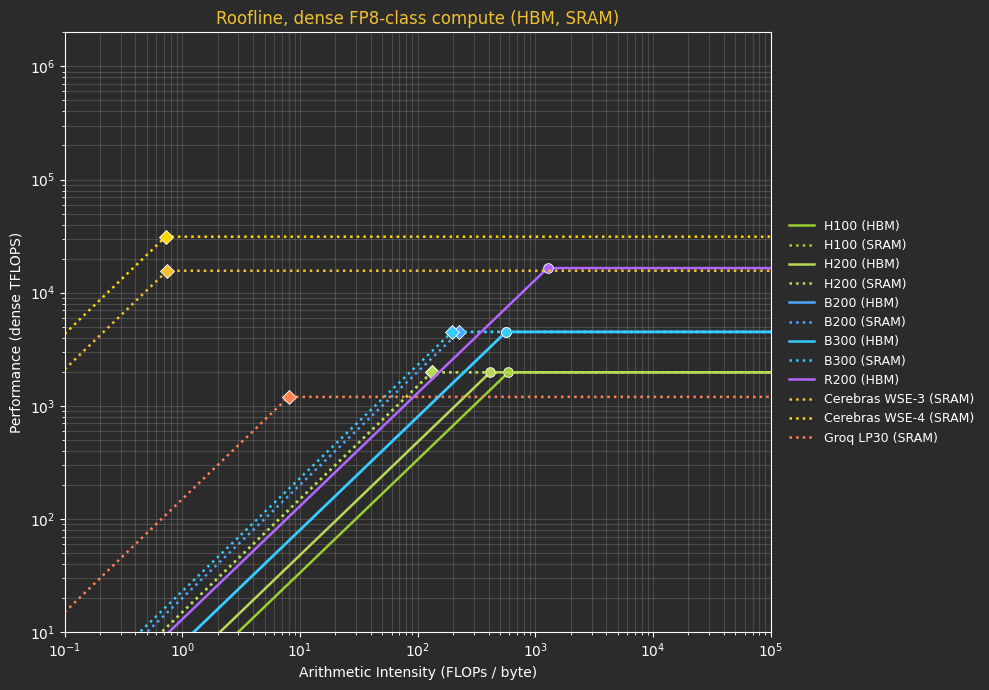

In [8]:
# name: (dense TFLOPS, bandwidth TB/s, die area mm^2, color, linestyle)
CHIPS = {
    "H100 (HBM)":              (1979,   3.35,    814, "#9acd32", "-"),
    "H100 (SRAM)":             (1979,   15.0,    814, "#9acd32", ":"),
    "H200 (HBM)":              (1979,   4.8,     814, "#b8d957", "-"),
    "H200 (SRAM)":             (1979,   15.0,    814, "#b8d957", ":"),
    "B200 (HBM)":              (4500,   8.0,    1600, "#4da6ff", "-"),
    "B200 (SRAM)":             (4500,   20.0,   1600, "#4da6ff", ":"),
    "B300 (HBM)":              (4500,   8.0,    1600, "#33ccff", "-"),
    "B300 (SRAM)":             (4500,   23.0,   1600, "#33ccff", ":"),
    "R200 (HBM)":              (16500,  13.0,   1600, "#b366ff", "-"),
    "Cerebras WSE-3 (SRAM)":   (15625,  21000, 46225, "#f0c030", ":"),
    "Cerebras WSE-4 (SRAM)":  (31250,  43200, 46225, "#ffd700", ":"),
    "Groq LP30 (SRAM)":        (1200,   150,     725, "#ff8050", ":"),
}

AI = np.logspace(-1, 5, 600)

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10, 7), facecolor="#2b2b2b")
ax.set_facecolor("#2b2b2b")

print(f"{'chip':26s} {'dense TFLOPS':>13s} {'ridge AI':>9s}")
for name, (peak, bw, area, color, ls) in CHIPS.items():
    perf = np.minimum(peak, AI * bw)
    ridge = peak / bw
    ax.plot(AI, perf, ls, color=color, lw=1.8, label=name)
    marker = "D" if ls == ":" else "o"
    ax.plot(ridge, peak, marker, color=color, ms=7,
            markeredgecolor="white", markeredgewidth=0.6)
    print(f"{name:26s} {peak:13.0f} {ridge:9.2f}")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.1, 1e5); ax.set_ylim(10, 2e6)
ax.set_xlabel("Arithmetic Intensity (FLOPs / byte)")
ax.set_ylabel("Performance (dense TFLOPS)")
ax.set_title("Roofline, dense FP8-class compute (HBM, SRAM)", color="#f0c030")
ax.grid(True, which="both", alpha=0.15)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=9)

fig.tight_layout()

chip                        TFLOPS/mm2   GB/s/mm2  ridge AI
H100 (HBM)                       2.431        4.1    590.75
H100 (SRAM)                      2.431       18.4    131.93
H200 (HBM)                       2.431        5.9    412.29
H200 (SRAM)                      2.431       18.4    131.93
B200 (HBM)                       2.812        5.0    562.50
B200 (SRAM)                      2.812       12.5    225.00
B300 (HBM)                       2.812        5.0    562.50
B300 (SRAM)                      2.812       14.4    195.65
R200 (HBM)                      10.312        8.1   1269.23
Cerebras WSE-3 (SRAM)            0.338      454.3      0.74
Cerebras WSE-4 (SRAM)            0.676      934.6      0.72
Groq LP30 (SRAM)                 1.655      206.9      8.00


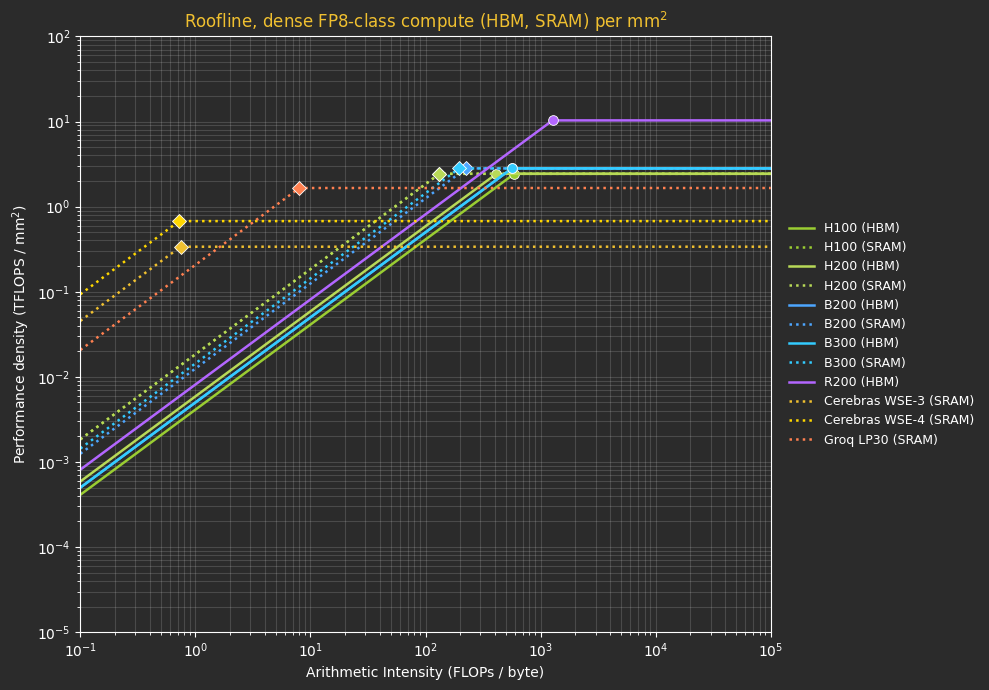

In [9]:
# name: (peak TFLOPS, BW TB/s, die area mm^2, color, linestyle)
# Areas: GH100 die 814; B200/B300 dual reticle die ~1600; R200 dual die ~1600 (est.);
# WSE-3 full wafer 46225; Groq LPU ~725 (est.).
CHIPS = {
    "H100 (HBM)":              (1979,   3.35,    814, "#9acd32", "-"),
    "H100 (SRAM)":             (1979,   15.0,    814, "#9acd32", ":"),
    "H200 (HBM)":              (1979,   4.8,     814, "#b8d957", "-"),
    "H200 (SRAM)":             (1979,   15.0,    814, "#b8d957", ":"),
    "B200 (HBM)":              (4500,   8.0,    1600, "#4da6ff", "-"),
    "B200 (SRAM)":             (4500,   20.0,   1600, "#4da6ff", ":"),
    "B300 (HBM)":              (4500,   8.0,    1600, "#33ccff", "-"),
    "B300 (SRAM)":             (4500,   23.0,   1600, "#33ccff", ":"),
    "R200 (HBM)":              (16500,  13.0,   1600, "#b366ff", "-"),
    "Cerebras WSE-3 (SRAM)":   (15625,  21000, 46225, "#f0c030", ":"),
    "Cerebras WSE-4 (SRAM)":  (31250,  43200, 46225, "#ffd700", ":"),
    "Groq LP30 (SRAM)":        (1200,   150,     725, "#ff8050", ":"),
}

AI = np.logspace(-1, 5, 600)

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10, 7), facecolor="#2b2b2b")
ax.set_facecolor("#2b2b2b")

print(f"{'chip':26s} {'TFLOPS/mm2':>11s} {'GB/s/mm2':>10s} {'ridge AI':>9s}")
for name, (peak, bw, area, color, ls) in CHIPS.items():
    p_d, b_d = peak / area, bw / area          # densities
    perf = np.minimum(p_d, AI * b_d)
    ridge = peak / bw                           # unchanged by normalization
    ax.plot(AI, perf, ls, color=color, lw=1.8, label=name)
    marker = "D" if ls == ":" else "o"
    ax.plot(ridge, p_d, marker, color=color, ms=7,
            markeredgecolor="white", markeredgewidth=0.6)
    print(f"{name:26s} {p_d:11.3f} {b_d*1000:10.1f} {ridge:9.2f}")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.1, 1e5); ax.set_ylim(1e-5, 1e2)
ax.set_xlabel("Arithmetic Intensity (FLOPs / byte)")
ax.set_ylabel("Performance density (TFLOPS / mm$^2$)")
ax.set_title("Roofline, dense FP8-class compute (HBM, SRAM) per mm$^2$", color="#f0c030")
ax.grid(True, which="both", alpha=0.15)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=9)

fig.tight_layout()

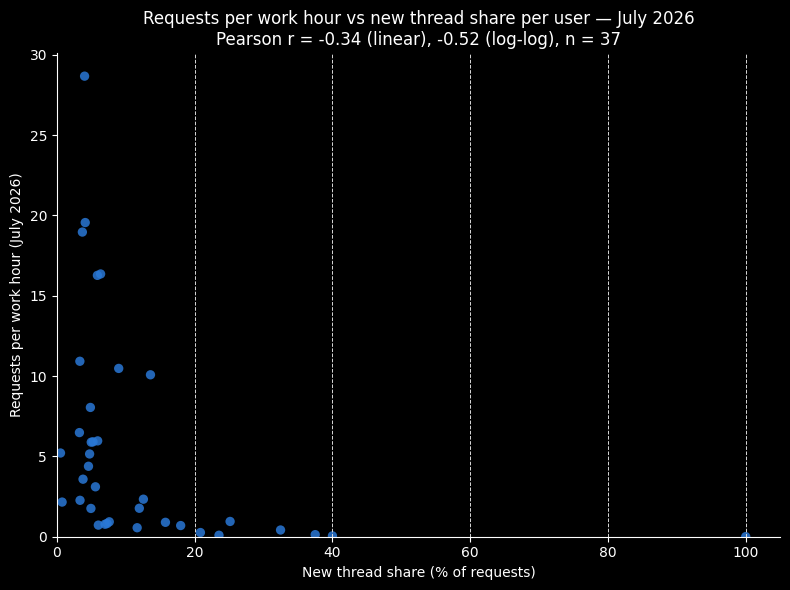

In [10]:
"""Scatter from claude-usage-july-2026.xlsx: X = new thread share (%), Y = requests.

Reads the 'July 2026' sheet, drops the Total row, plots one point per user.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE = "claude-usage-july-2026.xlsx"  # adjust path if needed

df = pd.read_excel(FILE, sheet_name="July 2026")
df = df[df["User"] != "Total"].copy()

x = df["New thread share (% of requests)"] * 100  # stored as fraction, render as %
y = df["Requests per work hour"]

r = np.corrcoef(x, y)[0, 1]
r_log = np.corrcoef(np.log(x.clip(lower=0.01)), np.log(y.clip(lower=1)))[0, 1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, s=45, color="#2A78D6", alpha=0.85, edgecolors="none")

ax.set_xlabel("New thread share (% of requests)")
ax.set_ylabel("Requests per work hour (July 2026)")
ax.set_title("Requests per work hour vs new thread share per user — July 2026\n"
             f"Pearson r = {r:.2f} (linear), {r_log:.2f} (log-log), n = {len(df)}")
ax.grid(axis="x", color="0.85", linestyle="--", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("requests_vs_new_thread_share.png", dpi=150)
plt.show()

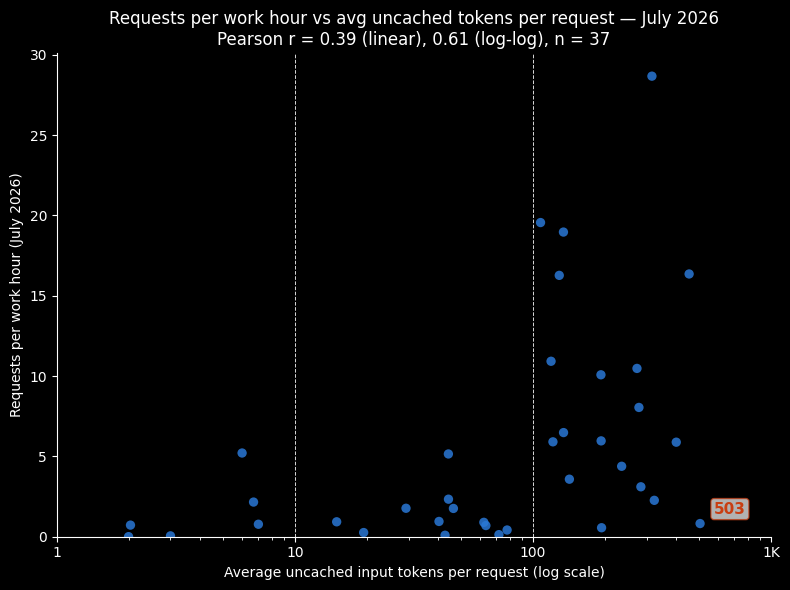

In [11]:
"""Scatter from claude-usage-july-2026.xlsx: X = average uncached input tokens per request,
Y = requests per work hour.

Reads the 'July 2026' sheet, drops the Total row, plots one point per user.
Ensures that x axis uses log scale and always includes 1000.
Labels the point with the maximum x axis value with its real value.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

FILE = "claude-usage-july-2026.xlsx"  # adjust path if needed

df = pd.read_excel(FILE, sheet_name="July 2026")
df = df[df["User"] != "Total"].copy()

df["Uncached per request"] = df["Uncached input tokens"] / df["Requests"]

x = df["Uncached per request"]
y = df["Requests per work hour"]

r = np.corrcoef(x, y)[0, 1]
r_log = np.corrcoef(np.log(x.clip(lower=0.1)), np.log(y.clip(lower=0.005)))[0, 1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, s=45, color="#2A78D6", alpha=0.85, edgecolors="none")

# Label the point with the highest x value (real value shown)
max_x_idx = x.idxmax()
max_x_val = x.loc[max_x_idx]
max_y_val = y.loc[max_x_idx]
ax.annotate(
    f"{max_x_val:,.0f}",
    (max_x_val, max_y_val),
    textcoords="offset points",
    xytext=(10, 5),
    ha='left',
    va='bottom',
    fontsize=11,
    fontweight='bold',
    color="#C93E12",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#C93E12", lw=1, alpha=0.7)
)

compact = FuncFormatter(lambda v, _: f"{v/1e3:.0f}K" if v >= 1e3 else f"{v:g}")
ax.set_xscale("log")

# Determine x limits and ensure 1000 is included
xmin, xmax = x.min(), x.max()
log_xmin = np.floor(np.log10(xmin))
log_xmax = np.ceil(np.log10(xmax))
# Make sure 1000 is inside limits
if 1000 < 10**log_xmin:
    log_xmin = 3.0
elif 1000 > 10**log_xmax:
    log_xmax = 3.0 if 3.0 > log_xmax else log_xmax
# Expand min/max to at least span 1000
if 10**log_xmin > 1000:
    log_xmin = 3.0
if 10**log_xmax < 1000:
    log_xmax = 3.0
ax.set_xlim(left=10**log_xmin, right=10**log_xmax)

ax.xaxis.set_major_formatter(compact)

ax.set_xlabel("Average uncached input tokens per request (log scale)")
ax.set_ylabel("Requests per work hour (July 2026)")
ax.set_title("Requests per work hour vs avg uncached tokens per request — July 2026\n"
             f"Pearson r = {r:.2f} (linear), {r_log:.2f} (log-log), n = {len(df)}")
ax.grid(axis="x", color="0.85", linestyle="--", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("req_per_hour_vs_uncached_per_request.png", dpi=150)
plt.show()

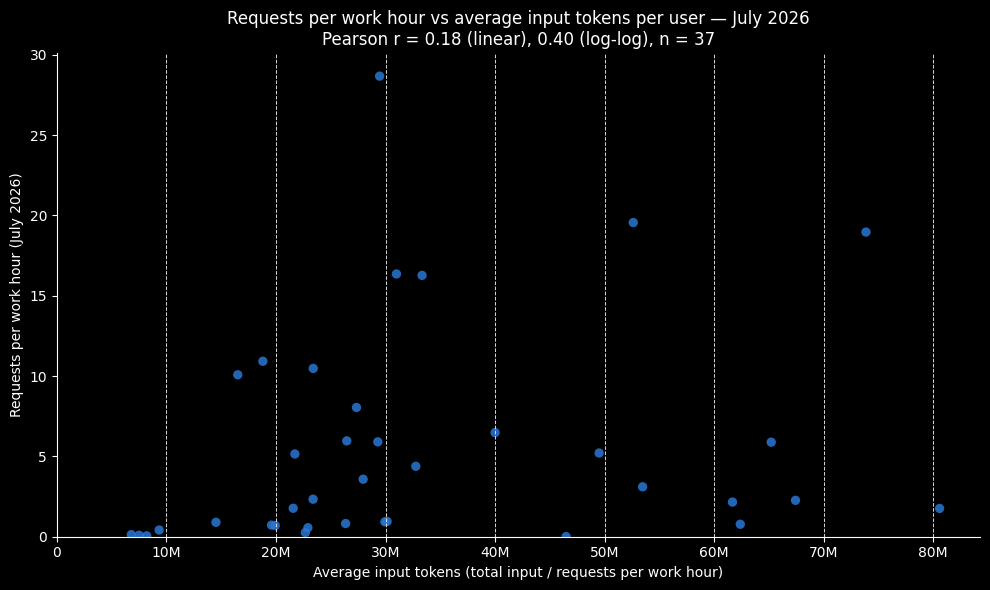

In [12]:
"""Scatter from claude-usage-july-2026.xlsx:
Y = requests per work hour, X = average input tokens (Total input tokens / Requests per work hour).

Note: dividing by requests-per-hour gives input tokens per hourly request rate, which equals
average tokens per request x 184 working hours (same shape, scaled X). For plain tokens per
request, use the commented line instead.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

FILE = "claude-usage-july-2026.xlsx"  # adjust path if needed

df = pd.read_excel(FILE, sheet_name="July 2026")
df = df[df["User"] != "Total"].copy()

df["Avg input tokens"] = df["Total input tokens"] / df["Requests per work hour"]
# alternative, per request instead of per hourly rate:
# df["Avg input tokens"] = df["Total input tokens"] / df["Requests"]

x = df["Avg input tokens"]
y = df["Requests per work hour"]

r = np.corrcoef(x, y)[0, 1]
r_log = np.corrcoef(np.log(x.clip(lower=1)), np.log(y.clip(lower=0.005)))[0, 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=45, color="#2A78D6", alpha=0.85, edgecolors="none")

compact = FuncFormatter(lambda v, _: f"{v/1e9:.1f}B" if v >= 1e9 else f"{v/1e6:.0f}M" if v >= 1e6 else f"{v/1e3:.0f}K" if v >= 1e3 else f"{v:.0f}")
ax.xaxis.set_major_formatter(compact)

ax.set_xlabel("Average input tokens (total input / requests per work hour)")
ax.set_ylabel("Requests per work hour (July 2026)")
ax.set_title("Requests per work hour vs average input tokens per user — July 2026\n"
             f"Pearson r = {r:.2f} (linear), {r_log:.2f} (log-log), n = {len(df)}")
ax.grid(axis="x", color="0.85", linestyle="--", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("req_per_hour_vs_avg_input_tokens.png", dpi=150)
plt.show()

         user   tok/req  interval no-cache $/d  cached $/d  saving  eff $/M
   Power user      211k      8.3m       367.34       41.83   88.6%    1.139
 Average user      300k     48.0m        90.00       30.69   65.9%    3.410

Power (bursty, 5m TTL) -> cached $29.43/day
First request example (211k ISL, 2k OSL, 1h write): $4.320  = 0.211M*$20 + 0.002M*$50  (no $10/M base charge)


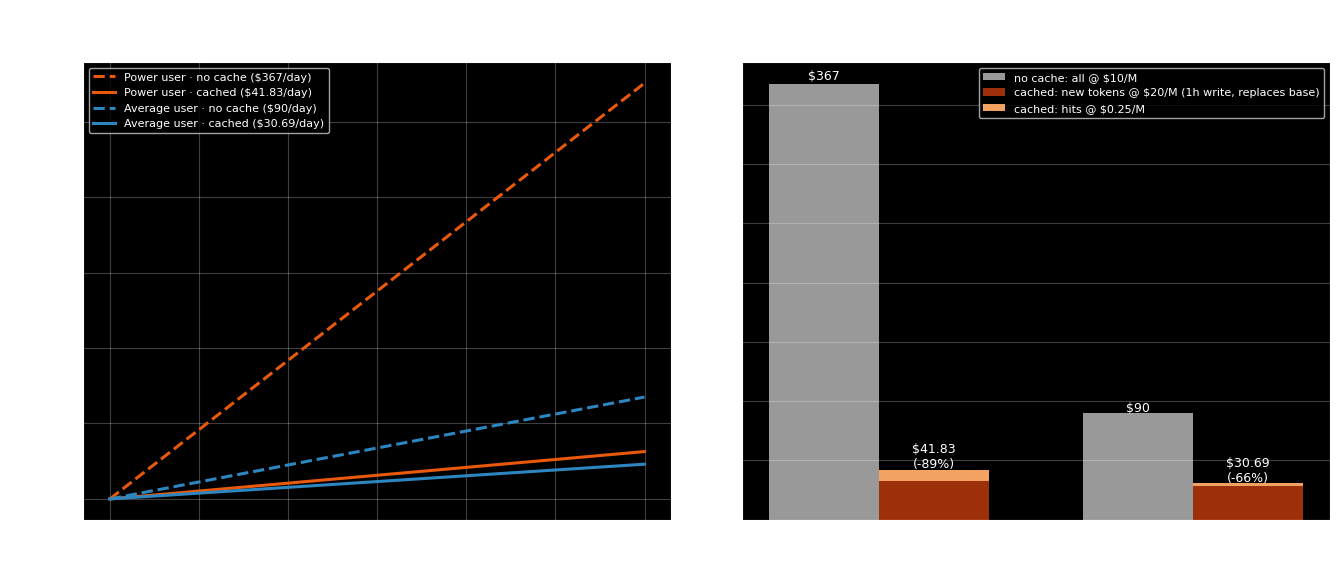

In [13]:
"""
Cost comparison of two user profiles under Claude Fable 5.1 pricing.
Prices verified against https://platform.claude.com/docs/en/about-claude/pricing
(fetched 2026-09-09):

  Base input        $10.00 /M
  5m cache write    $12.50 /M   (1.25x base -- REPLACES base input, not added)
  1h cache write    $20.00 /M   (2x base    -- REPLACES base input, not added)
  Cache hit         $ 0.25 /M   (0.025x base, Fable/Mythos 5.1 only)
  Output            $50.00 /M

CACHING SEMANTICS (per request, each input token is billed in exactly ONE bucket):
  - token already in cache        -> hit  @ $0.25/M  (hit refreshes the TTL)
  - token newly written to cache  -> write @ $12.50/M (5m) or $20/M (1h)
  - token neither cached nor written -> base input @ $10/M

  FIRST REQUEST (cold cache, whole prompt written, 1h TTL):
    cost = ISL/1e6 * 20 + OSL/1e6 * 50
  It is NOT  ISL*10 + ISL*20 + OSL*50 -- the write price is all-inclusive.

  In this steady-state model, "new fraction" tokens are the incremental
  prefix written each request; over a day every token is written exactly
  once and read on all later requests, so the cold first request is
  already captured by the aggregate new-token share.

  Power user   : 174 req/day, 36,733,936 total input tokens/day, 4.5% new
  Average user :  30 req/day,  9,000,000 total input tokens/day, 16%  new

  TTL forced by spacing (even-spacing over 24h):
    Power   ~8.3 min  > 5 min -> 1h writes @ $20/M
    Average ~48  min  > 5 min -> 1h writes @ $20/M
  Bursty power user (8h day -> 2.8 min) -> 5m writes @ $12.50/M (sensitivity).
  NO-CACHE baseline: all input tokens @ $10/M.
"""

import numpy as np
import matplotlib.pyplot as plt

# verified Fable 5.1 prices, $/M tokens
P_IN, P_W5, P_W1H, P_HIT, P_OUT = 10.0, 12.50, 20.0, 0.25, 50.0

USERS = {
    "Power user":   dict(req=174, tok_day=36_733_936, new=0.045,
                         color="#e8590c"),
    "Average user": dict(req=30,  tok_day=9_000_000,  new=0.16,
                         color="#2e86c1"),
}

def costs(u, p_write):
    """(no-cache $/day, cached $/day), input side only.
    Cached: new tokens billed ONLY at write price, rest ONLY at hit price."""
    m = u["tok_day"] / 1e6
    nc = m * P_IN
    ca = m * u["new"] * p_write + m * (1 - u["new"]) * P_HIT
    return nc, ca

def first_request_cost(isl, osl, p_write=P_W1H):
    """Cold-cache first request: full prompt is a cache write (no base
    input charge on the same tokens) + output tokens."""
    return isl / 1e6 * p_write + osl / 1e6 * P_OUT

print(f"{'user':>13} {'tok/req':>9} {'interval':>9} {'no-cache $/d':>12} "
      f"{'cached $/d':>11} {'saving':>7} {'eff $/M':>8}")
summary = {}
for name, u in USERS.items():
    u["tok_req"]  = u["tok_day"] / u["req"]
    u["interval"] = 24 * 60 / u["req"]              # minutes, even spacing
    p_w = P_W1H                                     # both intervals > 5 min
    nc, ca = costs(u, p_w)
    summary[name] = (nc, ca)
    print(f"{name:>13} {u['tok_req']/1e3:8.0f}k {u['interval']:8.1f}m "
          f"{nc:12.2f} {ca:11.2f} {1-ca/nc:7.1%} "
          f"{ca/(u['tok_day']/1e6):8.3f}")

# sensitivity: power user bursty (8h day -> 2.8 min interval -> 5m writes)
nc_p, ca_p_5m = costs(USERS["Power user"], P_W5)
print(f"\nPower (bursty, 5m TTL) -> cached ${ca_p_5m:.2f}/day")

# worked example: cold first request, 211k in / 2k out, 1h TTL
ex = first_request_cost(211_000, 2_000)
print(f"First request example (211k ISL, 2k OSL, 1h write): "
      f"${ex:.3f}  = 0.211M*$20 + 0.002M*$50  (no $10/M base charge)")

# ------------------------------- figure --------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.8), facecolor="white")

# Panel 1: cumulative cost over 30 days
days = np.linspace(0, 30, 200)
for name, u in USERS.items():
    nc, ca = summary[name]
    ax1.plot(days, days * nc, "--", color=u["color"], lw=2.2,
             label=f"{name} · no cache (${nc:,.0f}/day)")
    ax1.plot(days, days * ca, "-", color=u["color"], lw=2.2,
             label=f"{name} · cached (${ca:,.2f}/day)")
ax1.set_xlabel("days"); ax1.set_ylabel("cumulative input cost ($)")
ax1.set_title("Cumulative cost over a month", fontsize=10)
ax1.grid(alpha=0.25); ax1.legend(fontsize=8)

# Panel 2: pricing impact -- $/day decomposition, no-cache vs cached
x = np.arange(len(USERS)); w = 0.35
nc_v  = [summary[n][0] for n in USERS]
new_v = [USERS[n]["tok_day"]/1e6 * USERS[n]["new"] * P_W1H for n in USERS]
hit_v = [USERS[n]["tok_day"]/1e6 * (1-USERS[n]["new"]) * P_HIT for n in USERS]
ax2.bar(x - w/2, nc_v, w, color="#999", label="no cache: all @ $10/M")
ax2.bar(x + w/2, new_v, w, color="#9d2f0a",
        label="cached: new tokens @ $20/M (1h write, replaces base)")
ax2.bar(x + w/2, hit_v, w, bottom=new_v, color="#f4a261",
        label="cached: hits @ $0.25/M")
for i, n in enumerate(USERS):
    nc, ca = summary[n]
    ax2.text(i - w/2, nc * 1.01, f"${nc:,.0f}", ha="center", fontsize=9)
    ax2.text(i + w/2, ca * 1.05, f"${ca:,.2f}\n(-{1-ca/nc:.0%})",
             ha="center", fontsize=9)
ax2.set_xticks(x, list(USERS))
ax2.set_ylabel("$ per day (input side)")
ax2.set_title("Pricing impact: where the cached dollars go", fontsize=10)
ax2.grid(axis="y", alpha=0.25); ax2.legend(fontsize=8)

fig.suptitle("Power (174 req · 36.7M tok · 4.5% new) vs Average "
             "(30 req · 9M tok · 16% new) · Fable 5.1 pricing (verified)",
             fontsize=11)
fig.tight_layout()
fig.savefig("user_cost_compare_v3.png", dpi=150, bbox_inches="tight")
plt.show()